## 3주차 주제: AI 기반 데이터 모델링 및 OpenCV를 활용한 결과 시각화

3주차 업무 요청서(YOLOv8 기반 객체 탐지 및 OpenCV 결과 시각화)를 **어떤 순서로 진행해야 하는지**와 **각 단계가 왜 필요한지**를 함께 정리한 실행형 가이드이다.

Week 3의 목표는 **YOLOv8 사전 학습 모델로 객체 탐지 파이프라인을 구성하고, 탐지 결과와 모델 성능을 시각화하여 제출 가능한 형태로 정리하는 것**이다.

## 0. 전체 순서

3주차 업무 요청서의 흐름은 다음과 같다.

1. week3 브랜치 확인
2. 환경 설정
3. 폴더 구조 정리
4. data.yaml 작성
5. 사전 학습 모델로 탐지 데모
6. 학습 코드 정리 (train.py)
7. 탐지 코드 정리 (detect.py)
8. 평가 코드 정리 (evaluate.py)
9. 시각화 코드 정리 (visualize_metrics.py)
10. 성능 개선 실험 설계
11. 결과 분석 작성
12. GitHub 업로드

## 1. 라이브러리 설치

이번 과제에 필요한 최소 라이브러리는 아래와 같다.

- `torch`, `torchvision`: YOLOv8이 내부적으로 사용하는 딥러닝 프레임워크
- `ultralytics`: YOLOv8 모델 로드, 학습, 추론, 평가
- `opencv-python`: 이미지 로드와 바운딩 박스 시각화
- `numpy`: 좌표와 배열 연산
- `matplotlib`: 노트북에서 성능 지표 그래프를 확인

In [1]:
%pip install torch torchvision ultralytics opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. 프로젝트 폴더 구조 만들기

week3 README에 정리한 구조에 맞춰 폴더를 만든다.

```text
.
├── data.yaml
├── requirements.txt
├── train.py
├── detect.py
├── evaluate.py
├── visualize_metrics.py
├── datasets/
│   ├── train/
│   │   ├── images/
│   │   └── labels/
│   ├── valid/
│   │   ├── images/
│   │   └── labels/
│   └── test/
│       ├── images/
│       └── labels/
├── outputs/
│   ├── detection_results/
│   └── evaluation_results/
├── runs/
└── README.md
```


- `datasets/`: 학습·검증·테스트 이미지와 라벨을 분리해서 보관
- `outputs/`: 탐지 결과 이미지와 평가 그래프를 분리해서 저장
- `runs/`: YOLOv8 학습 시 자동으로 생성되는 로그/가중치 폴더

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "datasets"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DETECTION_OUTPUT_DIR = OUTPUT_DIR / "detection_results"
EVALUATION_OUTPUT_DIR = OUTPUT_DIR / "evaluation_results"
RUNS_DIR = PROJECT_ROOT / "runs"

directories = [
    DATASET_DIR / "train" / "images",
    DATASET_DIR / "train" / "labels",
    DATASET_DIR / "valid" / "images",
    DATASET_DIR / "valid" / "labels",
    DATASET_DIR / "test" / "images",
    DATASET_DIR / "test" / "labels",
    DETECTION_OUTPUT_DIR,
    EVALUATION_OUTPUT_DIR,
    RUNS_DIR,
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("프로젝트 루트:", PROJECT_ROOT)
print("생성 또는 확인한 폴더:")
for directory in directories:
    print("-", directory.relative_to(PROJECT_ROOT))

프로젝트 루트: C:\Users\sooin\Desktop\Comento_CV\proj\Comento_CV_proj\week3
생성 또는 확인한 폴더:
- datasets\train\images
- datasets\train\labels
- datasets\valid\images
- datasets\valid\labels
- datasets\test\images
- datasets\test\labels
- outputs\detection_results
- outputs\evaluation_results
- runs


## 3. 데이터셋 구성 및 `data.yaml` 작성

YOLO 객체 탐지 학습을 위해서는 이미지와 라벨 파일을 학습, 검증, 테스트로 분리해야 한다.

라벨 파일은 이미지 속 객체 정보를 아래 형식으로 저장한다.

```text
class_id x_center y_center width height
```

좌표와 크기는 이미지 전체 크기를 기준으로 `0~1` 범위로 정규화한다.

`data.yaml`은 데이터셋 경로와 클래스 정보를 YOLOv8에게 알려주는 설정 파일이다.

In [3]:
%%writefile data.yaml
train: ./datasets/train/images
val: ./datasets/valid/images
test: ./datasets/test/images

nc: 3
names:
  - person
  - car
  - dog

Overwriting data.yaml


## 3-1. 로보플로우 실제 데이터셋 적용

위 `data.yaml`은 업무 요청서의 예시(placeholder)였다. 실제로는 Roboflow Universe의 아래 데이터셋을 사용한다.

- 프로젝트: [`my-workspace-1/natural-object-detection`](https://universe.roboflow.com/my-workspace-1/natural-object-detection) (version 3)
- 라이선스: CC BY 4.0
- 규모: train 154장 / valid 25장 / test 13장 (총 192장, CPU 환경에서도 학습 가능한 크기)
- 클래스 22개: 실제 객체(`Person`, `Squirrel`, `cars`, `cats`, `cheetah`, `dogs`, `fox`, `frog`, `lion`, `owl`, `stop sign`, `tiger`, `traffic light`, `wolf`) + 촬영 조건 태그(`Blur`, `Camouflage`, `Foggy`, `Overlap`, `Patches`, `Poor lighting`, `Rain`, `Snow`)

> 참고: 같은 프로젝트의 version 1/2는 촬영 조건 태그 8개만 있고 실제 객체 클래스가 없어서, 실제 객체를 탐지하는 이번 과제 취지에 맞게 version 3을 선택했다.

### API 키 관리

Roboflow API 키는 `week3/.env`에 `ROBOFLOW_API_KEY=...` 형태로 저장하고, `week3/.gitignore`에 `.env`를 등록해 Git에 올라가지 않도록 했다. 노트북에서는 `python-dotenv`로 이 값을 읽어온다.

In [4]:
%pip install roboflow python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os

from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv()
api_key = os.environ.get("ROBOFLOW_API_KEY")
if not api_key:
    raise RuntimeError("week3/.env 파일에 ROBOFLOW_API_KEY를 설정해야 한다.")

rf = Roboflow(api_key=api_key)
project = rf.workspace("my-workspace-1").project("natural-object-detection")
version = project.version(3)

# datasets/ 폴더 바로 아래에 train/valid/test 구조로 받는다 (기존 빈 폴더를 실제 데이터로 채운다).
rf_dataset = version.download("yolov8", location=str(DATASET_DIR), overwrite=True)

print("데이터셋 다운로드 위치:", rf_dataset.location)


loading Roboflow workspace...



loading Roboflow project...



Extracting Dataset Version Zip to C:\Users\sooin\Desktop\Comento_CV\proj\Comento_CV_proj\week3\datasets in yolov8::   0%|          | 0/396 [00:00<?, ?it/s]


Extracting Dataset Version Zip to C:\Users\sooin\Desktop\Comento_CV\proj\Comento_CV_proj\week3\datasets in yolov8::  34%|███▍      | 136/396 [00:00<00:00, 1291.59it/s]


Extracting Dataset Version Zip to C:\Users\sooin\Desktop\Comento_CV\proj\Comento_CV_proj\week3\datasets in yolov8::  70%|██████▉   | 277/396 [00:00<00:00, 1346.78it/s]


Extracting Dataset Version Zip to C:\Users\sooin\Desktop\Comento_CV\proj\Comento_CV_proj\week3\datasets in yolov8:: 100%|██████████| 396/396 [00:00<00:00, 1365.23it/s]

데이터셋 다운로드 위치: C:\Users\sooin\Desktop\Comento_CV\proj\Comento_CV_proj\week3\datasets


In [6]:
%%writefile data.yaml
# Roboflow Universe: my-workspace-1/natural-object-detection (version 3, CC BY 4.0)
# https://universe.roboflow.com/my-workspace-1/natural-object-detection/dataset/3
train: ./datasets/train/images
val: ./datasets/valid/images
test: ./datasets/test/images

nc: 22
names:
  - Blur
  - Camouflage
  - Foggy
  - Overlap
  - Patches
  - Person
  - Poor lighting
  - Rain
  - Snow
  - Squirrel
  - cars
  - cats
  - cheetah
  - dogs
  - fox
  - frog
  - lion
  - owl
  - stop sign
  - tiger
  - traffic light
  - wolf

Overwriting data.yaml


### 데이터셋 확인

다운로드한 데이터가 정상인지, split별 이미지 수와 실제 라벨(Ground Truth) 박스를 확인한다.

train: 이미지 154장, 라벨 154개
valid: 이미지 25장, 라벨 25개
test: 이미지 13장, 라벨 13개

클래스 수: 22
클래스 목록: ['Blur', 'Camouflage', 'Foggy', 'Overlap', 'Patches', 'Person', 'Poor lighting', 'Rain', 'Snow', 'Squirrel', 'cars', 'cats', 'cheetah', 'dogs', 'fox', 'frog', 'lion', 'owl', 'stop sign', 'tiger', 'traffic light', 'wolf']


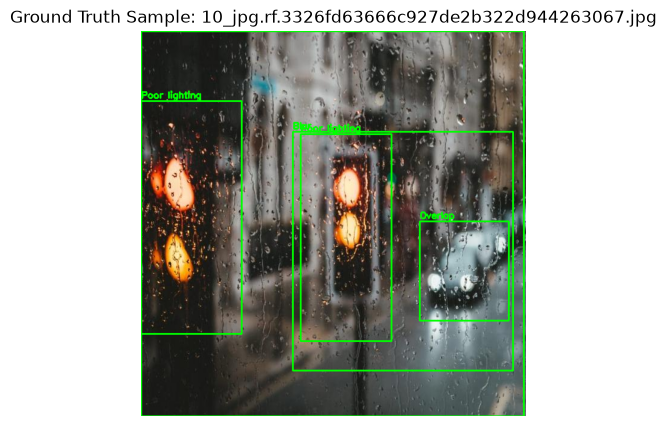

In [7]:
import cv2
import matplotlib.pyplot as plt
import yaml

data_config = yaml.safe_load(Path("data.yaml").read_text(encoding="utf-8"))
class_names = data_config["names"]

for split in ["train", "valid", "test"]:
    image_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"
    num_images = len(list(image_dir.glob("*.jpg")))
    num_labels = len(list(label_dir.glob("*.txt")))
    print(f"{split}: 이미지 {num_images}장, 라벨 {num_labels}개")

print("\n클래스 수:", data_config["nc"])
print("클래스 목록:", class_names)

# 학습 이미지 중 하나를 골라 Ground Truth 박스를 그려본다.
sample_image_path = sorted((DATASET_DIR / "train" / "images").glob("*.jpg"))[0]
sample_label_path = DATASET_DIR / "train" / "labels" / f"{sample_image_path.stem}.txt"

sample_image = cv2.imread(str(sample_image_path))
h, w = sample_image.shape[:2]

for line in sample_label_path.read_text(encoding="utf-8").splitlines():
    class_id, x_center, y_center, box_w, box_h = map(float, line.split())
    x1 = int((x_center - box_w / 2) * w)
    y1 = int((y_center - box_h / 2) * h)
    x2 = int((x_center + box_w / 2) * w)
    y2 = int((y_center + box_h / 2) * h)
    label = class_names[int(class_id)]

    cv2.rectangle(sample_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(sample_image, label, (x1, max(y1 - 5, 0)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))
plt.title(f"Ground Truth Sample: {sample_image_path.name}")
plt.axis("off")
plt.show()

## 4. 사전 학습 모델로 객체 탐지 데모

커스텀 데이터셋으로 학습하기 전에, **사전 학습된 `yolov8n.pt`가 정상적으로 로드되고 추론이 동작하는지** 먼저 확인한다.

이 단계는 Ultralytics 공식 예제 이미지(`bus.jpg`)를 사용한다. `person`, `car`(bus는 COCO의 `bus` 클래스) 등 COCO 80개 클래스를 그대로 탐지할 수 있어, 커스텀 데이터셋 없이도 파이프라인 동작을 바로 확인할 수 있다.

학습에는 시간이 걸리므로, 먼저 **추론 파이프라인(모델 로드 → 예측 → 시각화 → 저장)** 이 정상 동작하는지 가벼운 사전 학습 모델로 검증한 뒤 전이 학습으로 넘어가는 것이 효율적이다.

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


image 1/1 C:\Users\sooin\Desktop\Comento_CV\proj\Comento_CV_proj\week3\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 151.0ms


Speed: 5.0ms preprocess, 151.0ms inference, 14.1ms postprocess per image at shape (1, 3, 640, 480)


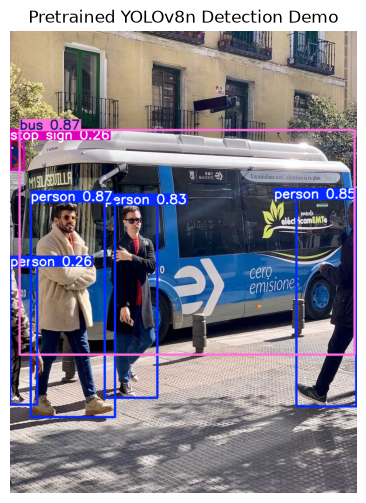

탐지된 객체 수: 6
결과 이미지 저장 위치: C:\Users\sooin\Desktop\Comento_CV\proj\Comento_CV_proj\week3\outputs\detection_results\pretrained_demo.jpg


In [8]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 사전 학습된 경량 모델(YOLOv8n)을 로드한다.
pretrained_model = YOLO("yolov8n.pt")

# Ultralytics 공식 예제 이미지를 사용해 탐지 파이프라인을 검증한다.
results = pretrained_model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    conf=0.25,
)

annotated_image = results[0].plot()  # BGR ndarray, 바운딩 박스/클래스/신뢰도가 그려진 이미지

demo_output_path = DETECTION_OUTPUT_DIR / "pretrained_demo.jpg"
cv2.imwrite(str(demo_output_path), annotated_image)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title("Pretrained YOLOv8n Detection Demo")
plt.axis("off")
plt.show()

print("탐지된 객체 수:", len(results[0].boxes))
print("결과 이미지 저장 위치:", demo_output_path)

## 5. YOLOv8 전이 학습 코드 (`train.py`)

사전 학습된 `yolov8n.pt`를 불러와 `data.yaml`에 정의한 사용자 데이터셋으로 전이 학습하는 코드를 작성한다.

전이 학습을 사용하면 처음부터 모델을 학습시키는 것보다 훨씬 적은 데이터와 시간으로도 쓸만한 성능을 얻을 수 있다.

In [9]:
%%writefile train.py
from ultralytics import YOLO


def main():
    # 사전 학습된 경량 모델을 불러온다.
    model = YOLO("yolov8n.pt")

    # data.yaml에 정의한 사용자 데이터셋으로 전이 학습을 수행한다.
    model.train(
        data="data.yaml",
        epochs=20,
        imgsz=640,
        batch=16,
        project="runs",
        name="week3_yolov8n",
    )


if __name__ == "__main__":
    main()

Overwriting train.py


## 6. 학습된 모델로 객체 탐지 (`detect.py`)

학습이 완료되면 `runs/week3_yolov8n/weights/best.pt` 가중치가 생성된다. 이 가중치로 테스트 이미지에서 객체를 탐지하는 코드를 작성한다.

탐지 결과에는 Bounding Box, 클래스명, Confidence, 이미지별 탐지 객체 수가 포함되어야 하며, 결과 이미지는 `outputs/detection_results/`에 저장하여 제출하였다.

In [ ]:
%%writefile detect.py
from pathlib import Path

import cv2
from ultralytics import YOLO

# 실제 학습(train.py) 실행 후 Ultralytics가 저장한 경로. 버전에 따라 project/name 아래에
# 'detect/' 하위 폴더가 한 번 더 추가될 수 있으니, 학습 로그의 save_dir을 확인해서 맞춘다.
WEIGHTS_PATH = "runs/detect/runs/week3_yolov8n/weights/best.pt"
TEST_IMAGE_DIR = Path("datasets/test/images")
OUTPUT_DIR = Path("outputs/detection_results")


def detect_and_save(model, image_path, output_dir):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"이미지를 읽을 수 없다: {image_path}")

    results = model(image)
    annotated_image = results[0].plot()

    output_path = output_dir / f"detected_{image_path.name}"
    cv2.imwrite(str(output_path), annotated_image)

    return output_path, len(results[0].boxes)


def main():
    output_dir = OUTPUT_DIR
    output_dir.mkdir(parents=True, exist_ok=True)

    model = YOLO(WEIGHTS_PATH)

    image_paths = sorted(TEST_IMAGE_DIR.glob("*.jpg"))
    if not image_paths:
        raise FileNotFoundError(f"테스트 이미지가 없다: {TEST_IMAGE_DIR}")

    for image_path in image_paths:
        output_path, num_objects = detect_and_save(model, image_path, output_dir)
        print(f"{image_path.name}: 탐지된 객체 수 {num_objects} -> {output_path}")


if __name__ == "__main__":
    main()

## 7. 모델 성능 평가 (`evaluate.py`)

검증 데이터셋을 기준으로 Precision, Recall, mAP50, mAP50-95를 확인하는 코드를 작성한다.

| 평가 지표 | 의미 |
|---|---|
| Precision | 탐지했다고 판단한 객체 중 실제 정답 비율 |
| Recall | 실제 객체 중 모델이 올바르게 탐지한 비율 |
| mAP50 | IoU 0.5 기준 평균 정밀도 |
| mAP50-95 | IoU 0.5~0.95 구간의 종합 평균 정밀도 |


객체 탐지 모델은 단순 Accuracy가 아니라 위 지표들로 평가해야 클래스별 성능과 오탐/미탐 경향을 파악할 수 있다.

In [ ]:
%%writefile evaluate.py
import json
from pathlib import Path

from ultralytics import YOLO

WEIGHTS_PATH = "runs/detect/runs/week3_yolov8n/weights/best.pt"
OUTPUT_PATH = Path("outputs/evaluation_results/metrics.json")


def main():
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

    model = YOLO(WEIGHTS_PATH)
    metrics = model.val(data="data.yaml")

    result = {
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map),
    }

    OUTPUT_PATH.write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")

    print("Precision:", result["precision"])
    print("Recall:", result["recall"])
    print("mAP50:", result["mAP50"])
    print("mAP50-95:", result["mAP50-95"])
    print("평가 결과 저장 위치:", OUTPUT_PATH)


if __name__ == "__main__":
    main()

## 8. 성능 시각화 (`visualize_metrics.py`)

`evaluate.py`가 저장한 `metrics.json`을 막대 그래프로 시각화하여 `outputs/evaluation_results/`에 저장한다.

In [ ]:
%%writefile visualize_metrics.py
import json
from pathlib import Path

import matplotlib

matplotlib.use("Agg")  # 스크립트로 실행할 때 GUI 창 없이 파일로만 저장한다.
import matplotlib.pyplot as plt

METRICS_PATH = Path("outputs/evaluation_results/metrics.json")
OUTPUT_PATH = Path("outputs/evaluation_results/metrics_bar_chart.png")


def main():
    metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))

    labels = list(metrics.keys())
    values = list(metrics.values())

    plt.figure(figsize=(6, 4))
    plt.bar(labels, values)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title("YOLOv8 Week3 Model Performance")
    plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")

    print("성능 그래프 저장 위치:", OUTPUT_PATH)


if __name__ == "__main__":
    main()

## 9. 성능 개선 실험 설계

기본 모델의 결과를 기준으로 아래 조건을 바꿔가며 성능을 비교한다.

### 데이터 증강

- 좌우 반전
- 이미지 회전
- 밝기 및 대비 조절
- Scale 및 Crop
- 노이즈 추가

```python
model.train(data="data.yaml", epochs=20, imgsz=640, augment=True)
```

### 하이퍼파라미터 조정

- Epoch 증가
- Batch Size 변경
- 입력 이미지 크기 변경
- Learning Rate 조정
- Confidence Threshold 조정

### 모델 크기 비교

| 모델 | 특징 |
|---|---|
| YOLOv8n | 가장 가볍고 빠름 |
| YOLOv8s | 속도와 정확도의 균형이 좋음 |
| YOLOv8m | 정확도가 높지만 연산량이 큼 |
#

> 정확도만 높이는 것이 아니라 추론 속도와 자원 사용량도 함께 비교해야, 실제 서비스에 어떤 모델이 적합한지 판단할 수 있다.

## 10. 결과

`train.py`(CPU, 1.15시간), `detect.py`, `evaluate.py`, `visualize_metrics.py`를 실제로 실행한 결과는 다음과 같다.

| 항목 | 결과 |
|---|---|
| 사용 모델 | YOLOv8n |
| Epoch | 20 |
| 이미지 크기 | 640 |
| 클래스 수 | 22 |
| Precision | 0.200 |
| Recall | 0.296 |
| mAP50 | 0.371 |
| mAP50-95 | 0.281 |
| 추론 시간 | 약 70~170ms/이미지 (CPU) |

이미지 192장(train 154 / valid 25 / test 13)이라는 적은 데이터와 20 epoch만으로는 Precision/Recall이 낮은 편이다(특히 `Person`, `Squirrel`, `traffic light`처럼 인스턴스가 1~2개뿐인 클래스는 거의 탐지되지 않았다). `Patches`(mAP50 0.963), `Rain`(0.995)처럼 인스턴스 수가 상대적으로 많거나 시각적으로 뚜렷한 클래스는 성능이 높았다.

탐지 결과 이미지: `outputs/detection_results/`
성능 평가 그래프: `outputs/evaluation_results/metrics_bar_chart.png`